Musculoskeletal / Trauma 

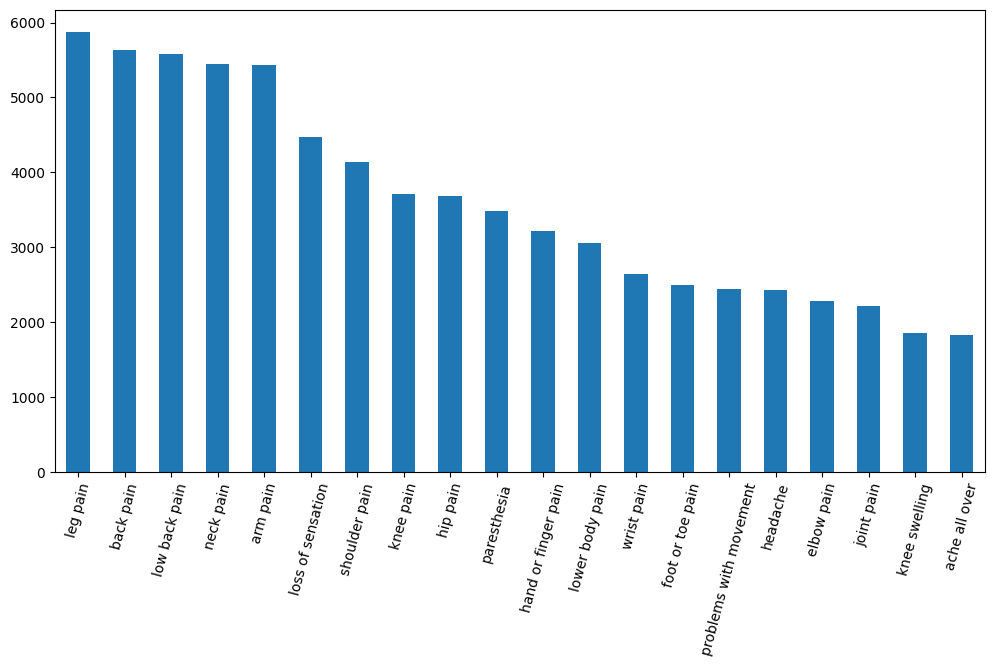

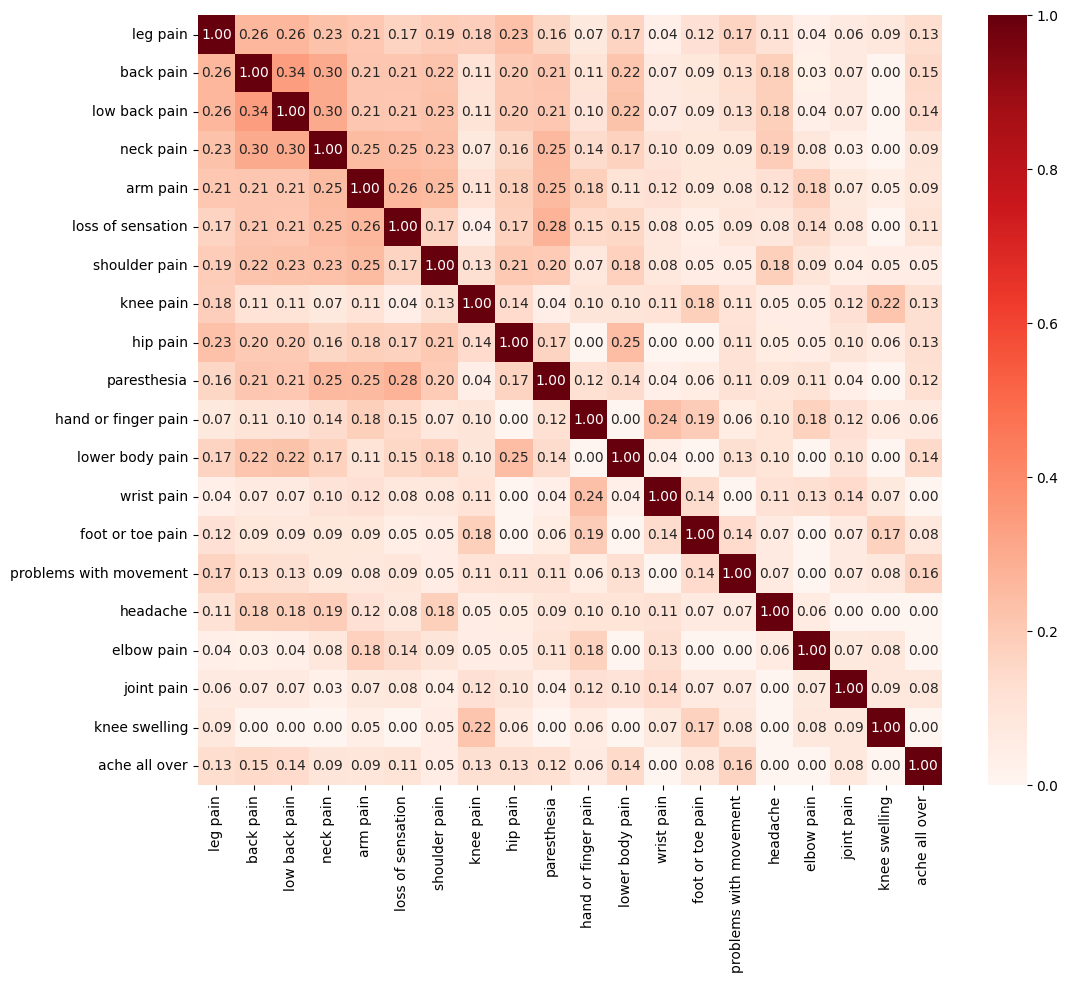

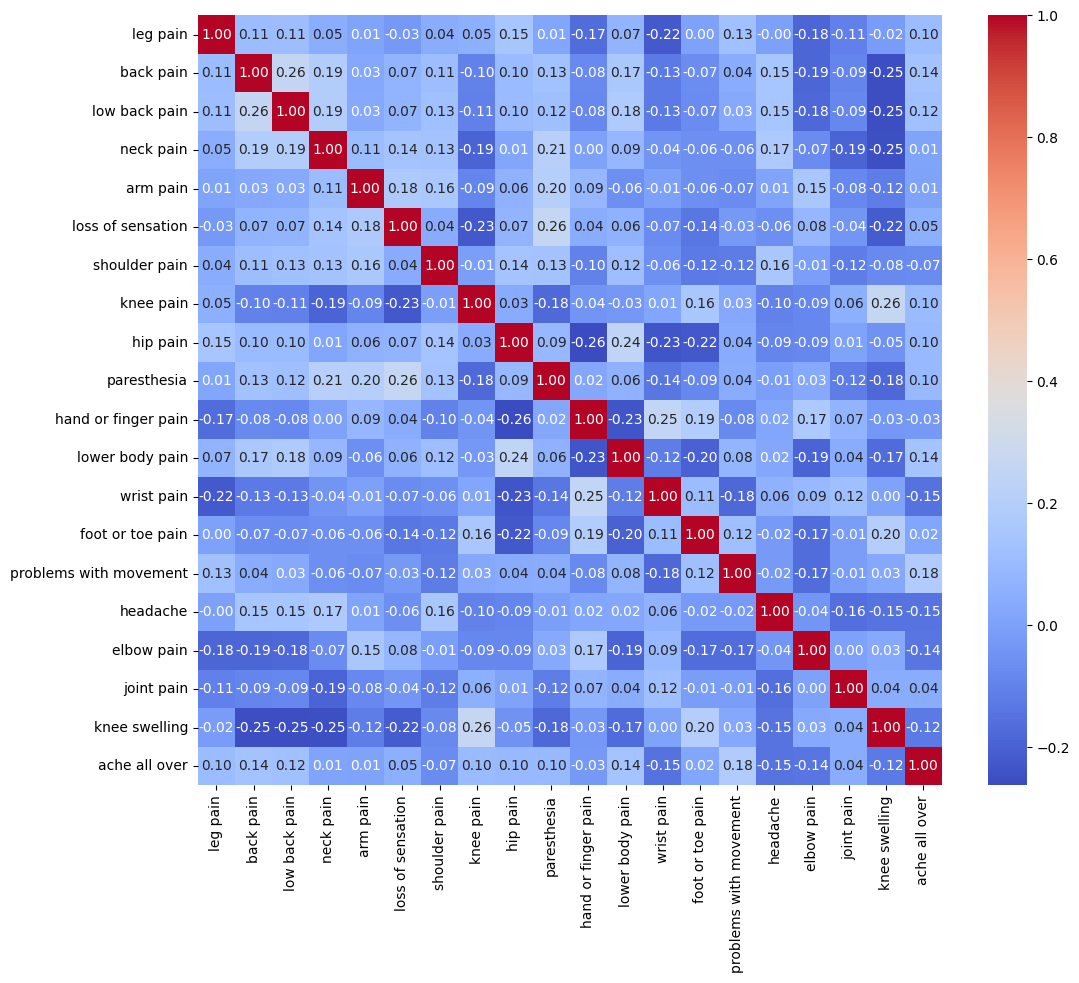

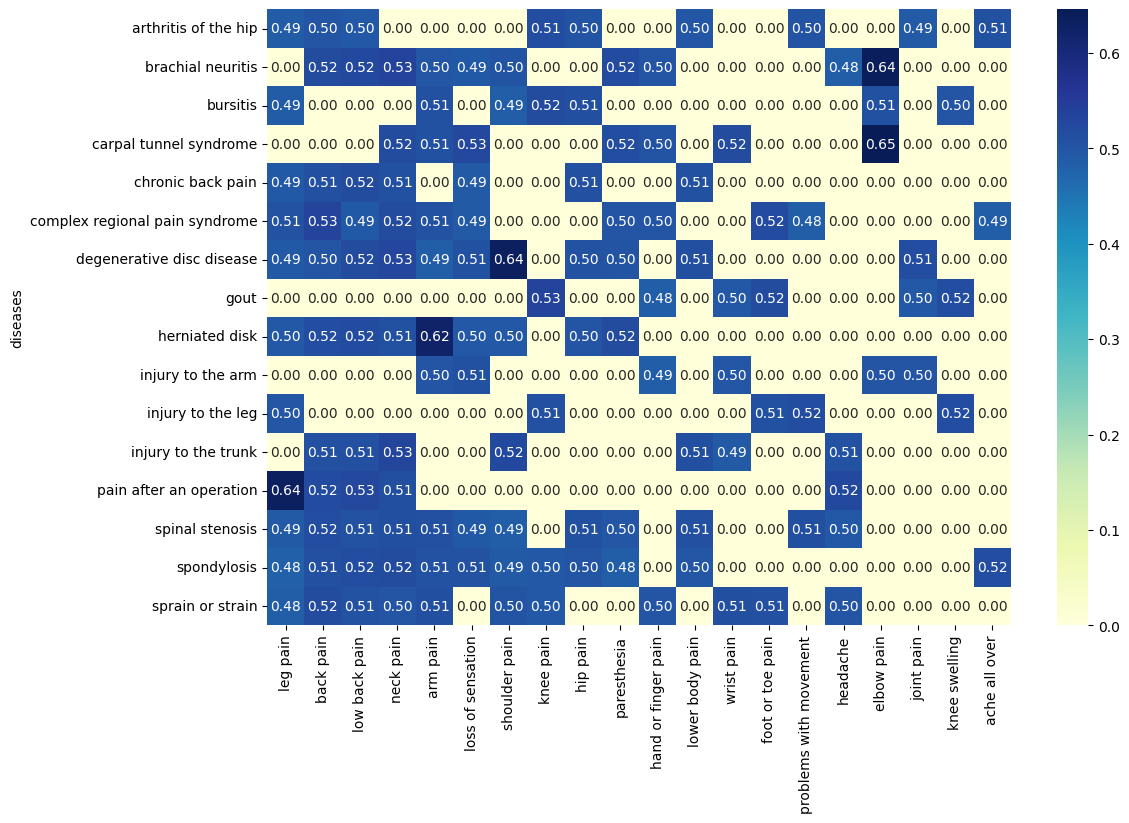

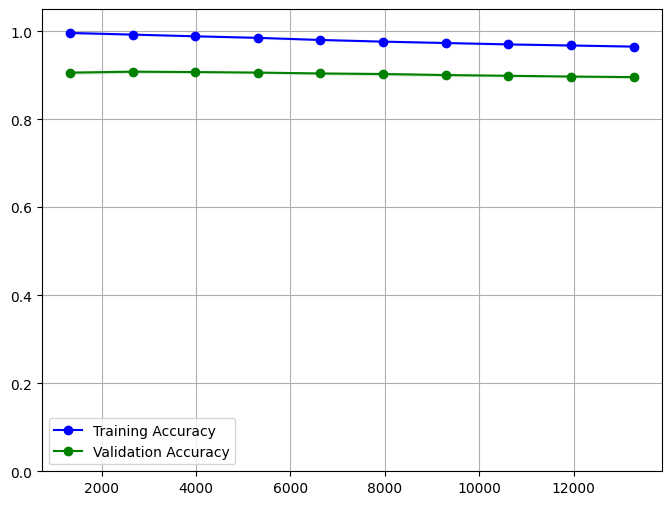

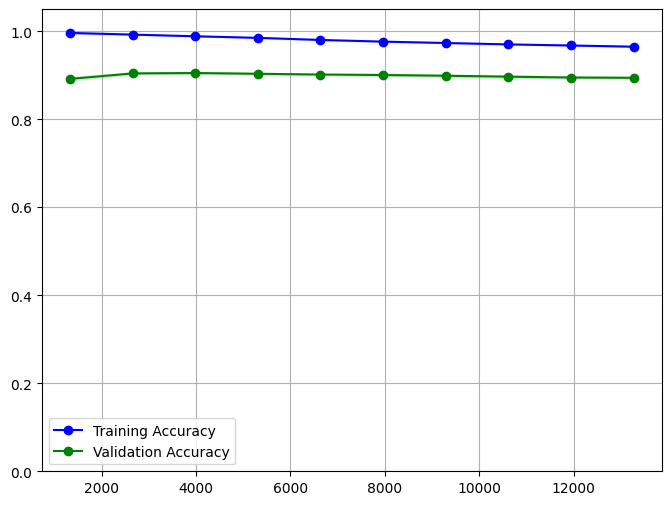

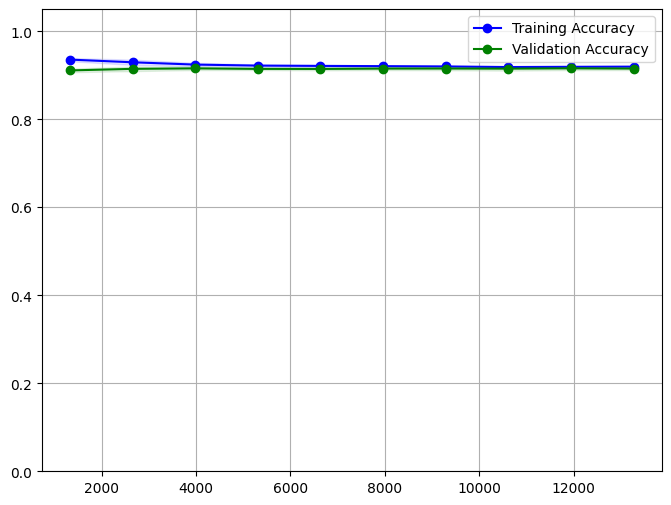

Random Forest Accuracy: 0.8948
                                precision    recall  f1-score   support

          arthritis of the hip       0.98      0.97      0.97       242
             brachial neuritis       0.89      0.82      0.85       165
                      bursitis       0.99      1.00      0.99       242
        carpal tunnel syndrome       0.94      0.95      0.94       164
             chronic back pain       0.94      0.97      0.95       161
complex regional pain syndrome       0.92      0.89      0.90       244
     degenerative disc disease       0.54      0.59      0.57       162
                          gout       0.96      0.98      0.97       242
                herniated disk       0.67      0.75      0.71       166
             injury to the arm       0.98      0.97      0.97       242
             injury to the leg       0.99      0.96      0.98       241
           injury to the trunk       1.00      0.97      0.98       161
       pain after an operation  

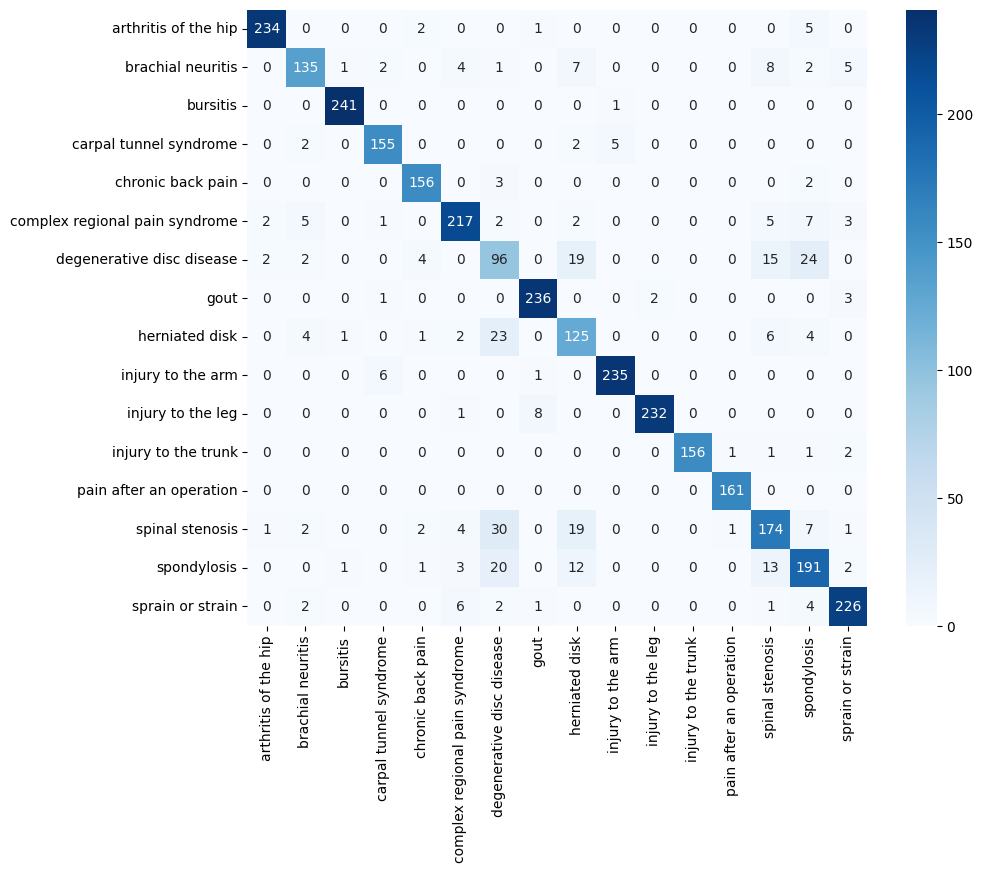

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [20:42:14] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.8930
                                precision    recall  f1-score   support

          arthritis of the hip       0.98      0.98      0.98       242
             brachial neuritis       0.86      0.84      0.85       165
                      bursitis       0.99      1.00      0.99       242
        carpal tunnel syndrome       0.94      0.93      0.94       164
             chronic back pain       0.95      0.97      0.96       161
complex regional pain syndrome       0.89      0.89      0.89       244
     degenerative disc disease       0.57      0.55      0.56       162
                          gout       0.96      0.98      0.97       242
                herniated disk       0.69      0.74      0.72       166
             injury to the arm       0.97      0.98      0.97       242
             injury to the leg       0.98      0.96      0.97       241
           injury to the trunk       0.99      0.98      0.98       161
       pain after an operation       0

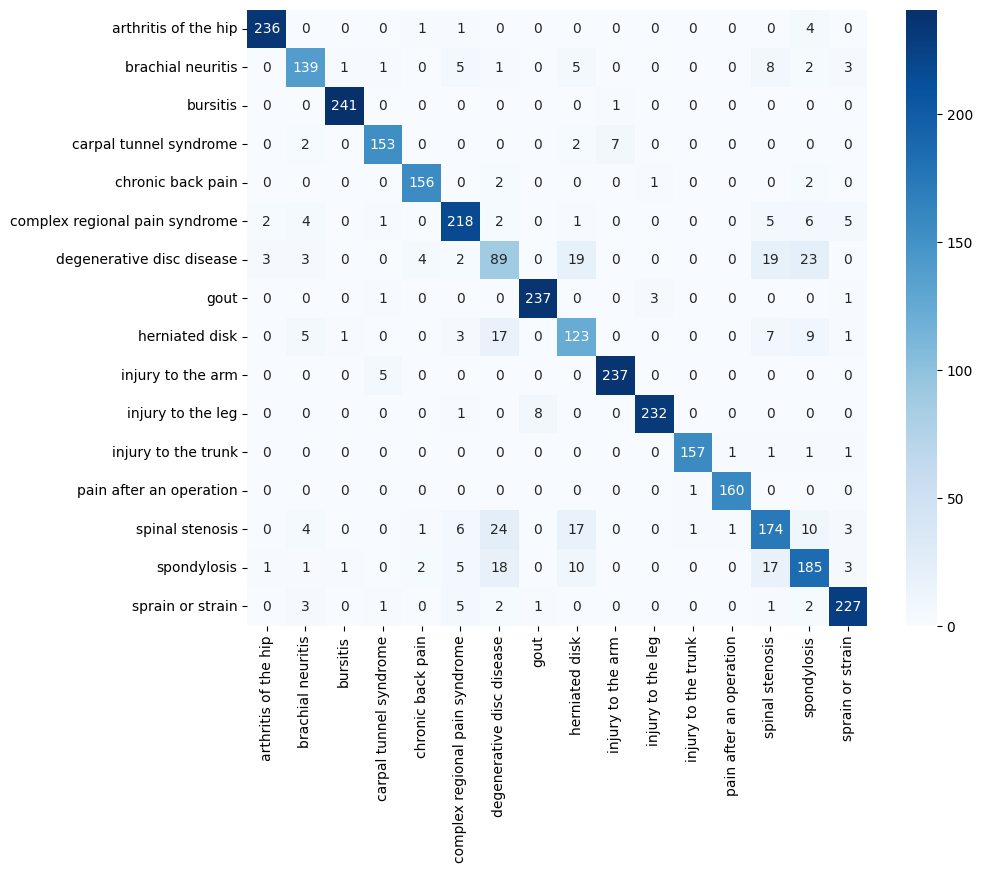

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:1273: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


Logistic Regression Accuracy: 0.9159
                                precision    recall  f1-score   support

          arthritis of the hip       1.00      0.97      0.98       242
             brachial neuritis       0.95      0.84      0.89       165
                      bursitis       1.00      1.00      1.00       242
        carpal tunnel syndrome       0.94      0.96      0.95       164
             chronic back pain       0.98      0.98      0.98       161
complex regional pain syndrome       0.96      0.91      0.93       244
     degenerative disc disease       0.56      0.84      0.67       162
                          gout       0.95      0.98      0.97       242
                herniated disk       0.67      0.85      0.75       166
             injury to the arm       1.00      0.97      0.98       242
             injury to the leg       1.00      0.95      0.98       241
           injury to the trunk       0.99      0.98      0.98       161
       pain after an opera

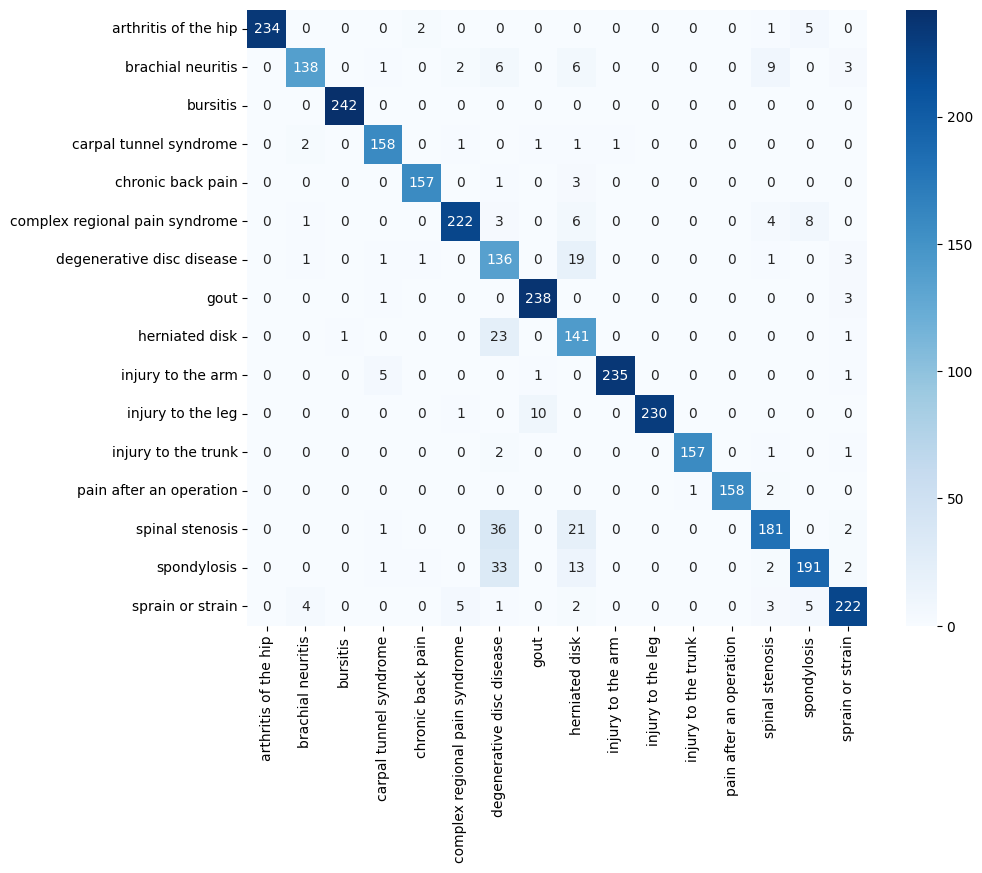

C:\Users\Admin\AppData\Local\Temp\ipykernel_20396\3657009932.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


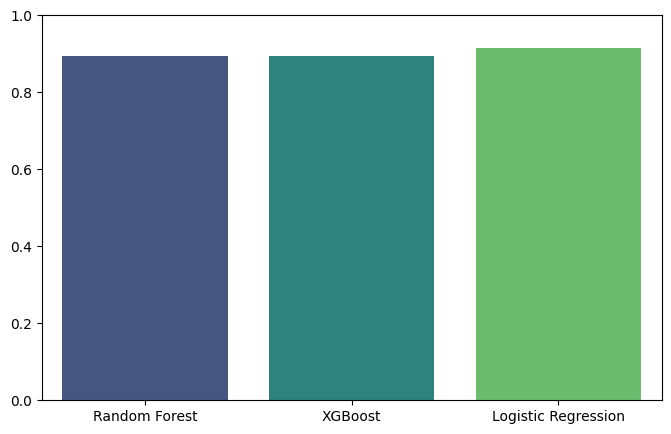

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import jaccard_score, classification_report, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import xgboost as xgb

df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

msk_diseases = [
    'bursitis', 'spondylosis', 'injury to the arm', 'complex regional pain syndrome',
    'injury to the trunk', 'degenerative disc disease', 'pain after an operation',
    'injury to the leg', 'carpal tunnel syndrome', 'arthritis of the hip',
    'spinal stenosis', 'sprain or strain', 'chronic back pain', 'herniated disk',
    'brachial neuritis', 'gout'
]

disease_col = 'diseases'
symptom_cols = [c for c in df.columns if c != disease_col]

df_msk = df[df[disease_col].isin(msk_diseases)]
selected_symptoms = df_msk[symptom_cols].sum()[lambda x: x>0].index.tolist()

X = df_msk[selected_symptoms]
y = df_msk[disease_col]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

symptom_counts = df_msk[symptom_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind='bar')
plt.xticks(rotation=75)
plt.show()

top_symptoms = symptom_counts.head(20).index.tolist()
jaccard_matrix = np.zeros((len(top_symptoms), len(top_symptoms)))
for i, s1 in enumerate(top_symptoms):
    for j, s2 in enumerate(top_symptoms):
        jaccard_matrix[i,j] = jaccard_score(df_msk[s1], df_msk[s2])

plt.figure(figsize=(12,10))
sns.heatmap(jaccard_matrix, xticklabels=top_symptoms, yticklabels=top_symptoms, cmap='Reds', annot=True, fmt=".2f")
plt.show()

corr_matrix = df_msk[symptom_cols].corr()
plt.figure(figsize=(12,10))
sns.heatmap(corr_matrix.loc[top_symptoms, top_symptoms], cmap='coolwarm', annot=True, fmt=".2f")
plt.show()

disease_symptom_prob = df_msk.groupby(disease_col)[symptom_cols].mean()
plt.figure(figsize=(12,8))
sns.heatmap(disease_symptom_prob[top_symptoms], cmap='YlGnBu', annot=True, fmt=".2f")
plt.show()

models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, learning_rate=0.3, n_estimators=500),
    "Logistic Regression": LogisticRegression(max_iter=2000, class_weight='balanced', multi_class='ovr', C=1)
}

def plot_learning_curve(estimator, X, y, model_name):
    train_sizes, train_scores, val_scores = learning_curve(
        estimator, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='accuracy', n_jobs=-1, shuffle=True, random_state=42
    )
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    val_mean = np.mean(val_scores, axis=1)
    val_std = np.std(val_scores, axis=1)
    plt.figure(figsize=(8,6))
    plt.plot(train_sizes, train_mean, 'o-', color='blue', label='Training Accuracy')
    plt.fill_between(train_sizes, train_mean-train_std, train_mean+train_std, alpha=0.1, color='blue')
    plt.plot(train_sizes, val_mean, 'o-', color='green', label='Validation Accuracy')
    plt.fill_between(train_sizes, val_mean-val_std, val_mean+val_std, alpha=0.1, color='green')
    plt.ylim(0,1.05)
    plt.grid(True)
    plt.legend()
    plt.show()

for name, model in models.items():
    plot_learning_curve(model, X, y_encoded, name)

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    results[name] = accuracy
    print(f"{name} Accuracy: {accuracy:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylim(0,1)
plt.show()
